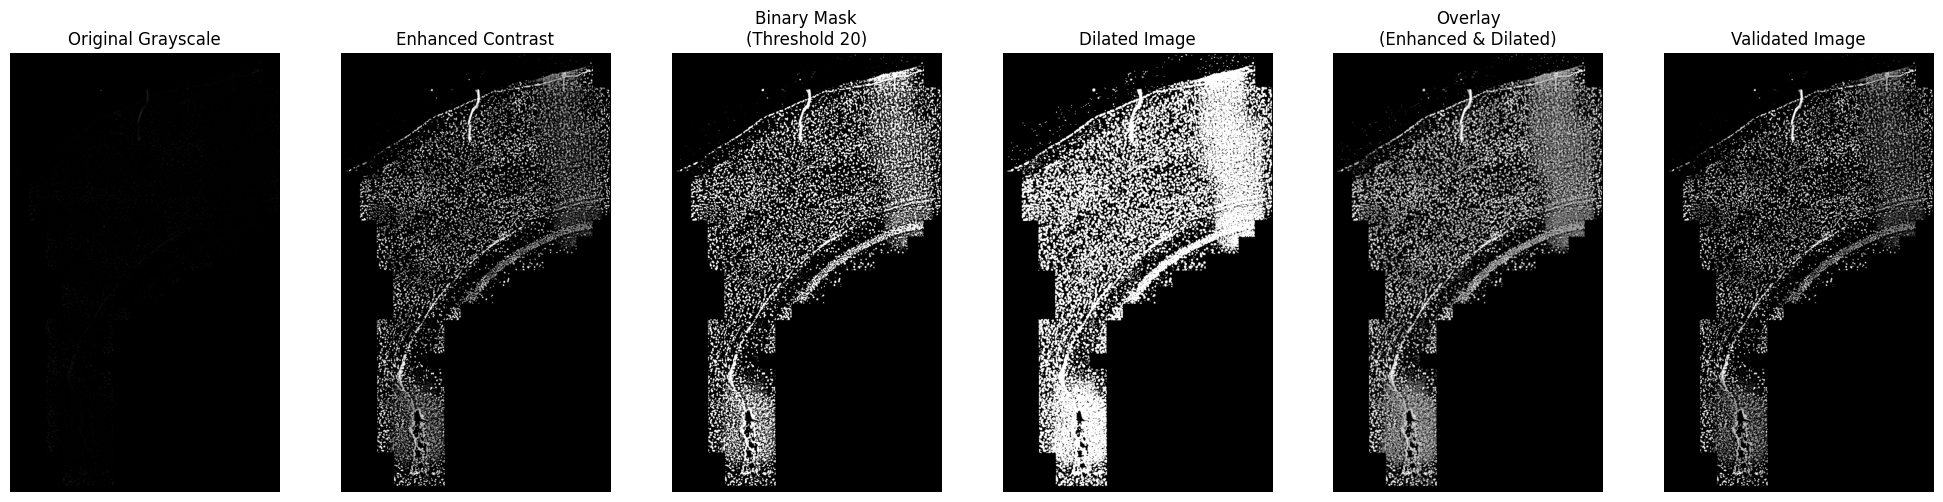

In [3]:
import cv2
import numpy as np
import pickle
import matplotlib.pyplot as plt

# Step 1: Load the osmFISH image data
file_to_load = "/kaggle/input/merfish-multiplexed-smfish-osmfish-3dataset/supplemental_data_ssam_2019/osmFISH/raw_data/im_nuc_small.pickle"
with open(file_to_load, 'rb') as f:
    nuclei_data = pickle.load(f)

# Convert nuclei data to uint8 for processing
if len(nuclei_data.shape) == 3:
    gray_image = cv2.cvtColor(nuclei_data, cv2.COLOR_RGB2GRAY)
else:
    gray_image = nuclei_data
gray_image = ((gray_image - gray_image.min()) / (gray_image.max() - gray_image.min()) * 255).astype('uint8')

# Step 2: Apply histogram equalization to enhance contrast
enhanced_image = cv2.equalizeHist(gray_image)

# Step 3: Apply Thresholding with a fixed value
threshold_value = 20
_, binary_mask = cv2.threshold(enhanced_image, threshold_value, 255, cv2.THRESH_BINARY)

# Step 4: Apply Dilation with a 5x5 kernel
kernel = np.ones((5, 5), np.uint8)
dilated_image = cv2.dilate(binary_mask, kernel, iterations=1)

# Step 5: Overlay the dilated mask on the enhanced image
overlay = cv2.addWeighted(enhanced_image, 0.7, dilated_image, 0.3, 0)

# Step 6: Validate the results by multiplying the enhanced image with the binary mask
validated_image = cv2.bitwise_and(enhanced_image, enhanced_image, mask=dilated_image)

# Horizontal Visualization
fig, axs = plt.subplots(1, 6, figsize=(20, 5))

# Original grayscale image
axs[0].imshow(gray_image, cmap='gray')
axs[0].set_title("Original Grayscale")
axs[0].axis('off')

# Enhanced contrast image
axs[1].imshow(enhanced_image, cmap='gray')
axs[1].set_title("Enhanced Contrast")
axs[1].axis('off')

# Binary mask
axs[2].imshow(binary_mask, cmap='gray')
axs[2].set_title(f"Binary Mask\n(Threshold {threshold_value})")
axs[2].axis('off')

# Dilated image
axs[3].imshow(dilated_image, cmap='gray')
axs[3].set_title("Dilated Image")
axs[3].axis('off')

# Overlay
axs[4].imshow(overlay, cmap='gray')
axs[4].set_title("Overlay\n(Enhanced & Dilated)")
axs[4].axis('off')

# Validated image
axs[5].imshow(validated_image, cmap='gray')
axs[5].set_title("Validated Image")
axs[5].axis('off')

plt.tight_layout()
plt.show()
